In [13]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import scipy.stats as stats

df = pd.read_csv("./data/soccer-players.csv")
df.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='object')

In [14]:
df.sample(18)

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
2247,26741,Leonel,Núñez,Leonel Núñez,2013,653,leonel-nunez,Argentina,Capital Federal,Argentina,...,right,185.0,NaN,Gold Players S.A.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/leonel-nunez/p...,GR1,Omilos Filathlon Irakliou FC,100000.0,2700000.0
22641,457522,Batuhan,Ünsal,Batuhan Ünsal,2020,39722,batuhan-unsal,Turkey,Antalya,Turkey,...,right,185.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/batuhan-unsal/...,TR1,Erzurumspor FK,25000.0,50000.0
8226,110622,Jonathan,Mensah,Jonathan Mensah,2016,2700,jonathan-mensah,Ghana,Accra,Ghana,...,right,188.0,2023-12-31 00:00:00,CAA Stellar,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/jonathan-mensa...,RU1,Anzhi Makhachkala ( -2022),500000.0,1750000.0
14313,239951,Andrej,Lukic,Andrej Lukic,2018,1283,andrej-lukic,Croatia,Nova Gradiška,Croatia,...,right,190.0,2024-06-30 00:00:00,HBR Sport,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/andrej-lukic/p...,NL1,FC Emmen,400000.0,800000.0
27529,658835,Kader,Keita,Kader Keita,2023,2381,kader-keita,NaN,NaN,Cote d'Ivoire,...,right,178.0,2026-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/kader-keita/pr...,TR1,Sivasspor Kulübü,750000.0,900000.0
5873,67252,Ryan,Bennett,Ryan Bennett,2019,1003,ryan-bennett,England,Orsett,England,...,right,188.0,2023-06-30 00:00:00,World in Motion,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/ryan-bennett/p...,GB1,Leicester City Football Club,250000.0,7000000.0
24514,532792,Islam,Zhilov,Islam Zhilov,2017,2700,islam-zhilov,Russia,"Nartkala, Kabardino-Balkar Republic",Russia,...,right,174.0,2023-12-31 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/islam-zhilov/p...,RU1,Anzhi Makhachkala ( -2022),250000.0,250000.0
5645,63047,Milan,Skoda,Milan Skoda,2020,126,milan-skoda,CSSR,Praha,Czech Republic,...,right,190.0,2023-06-30 00:00:00,MSG-Agency,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/milan-skoda/pr...,TR1,Çaykur Rizespor Kulübü,175000.0,2250000.0
7024,85969,Oleksandr,Bandura,Oleksandr Bandura,2023,61825,oleksandr-bandura,UdSSR,"Gamaliivka, Sumy Oblast",Ukraine,...,right,186.0,2025-06-30 00:00:00,Igor Shutov,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/oleksandr-band...,UKR1,FC Minaj,150000.0,1500000.0
15327,260393,Michael,Rangel,Michael Rangel,2017,10484,michael-rangel,Colombia,Floridablanca,Colombia,...,right,188.0,NaN,Riosfutbol,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/michael-rangel...,TR1,Kasımpaşa Spor Kulübü,300000.0,1500000.0


In [15]:
df = df[["name", "position", "date_of_birth", "height_in_cm"]]
df = df.loc[df["height_in_cm"] > 150]
df.head()

,name,position,date_of_birth,height_in_cm
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0
7,Tomas Rosicky,Midfield,1980-10-04 00:00:00,179.0
8,Marc Ziegler,Goalkeeper,1976-06-13 00:00:00,193.0


In [16]:
df["month"] = pd.to_datetime(df["date_of_birth"]).dt.month
df.head()

,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0
7,Tomas Rosicky,Midfield,1980-10-04 00:00:00,179.0,10.0
8,Marc Ziegler,Goalkeeper,1976-06-13 00:00:00,193.0,6.0


In [17]:
df = df.dropna(subset=["height_in_cm"])
df.head()

,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0
7,Tomas Rosicky,Midfield,1980-10-04 00:00:00,179.0,10.0
8,Marc Ziegler,Goalkeeper,1976-06-13 00:00:00,193.0,6.0


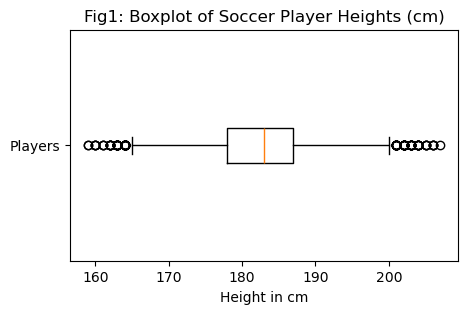

In [26]:
plt.figure(figsize=(5,3))
plt.boxplot(x=df["height_in_cm"],orientation="horizontal")
plt.title("Fig1: Boxplot of Soccer Player Heights (cm)")
plt.xlabel("Height in cm")
plt.yticks(ticks=[1], labels=["Players"])
plt.show()

- Red line = Median
- Box area = IQR (Q3 - Q1)
- Whisker right = Q3 + (IQR * 1.5)
- Whisker left = Q1 - (IQR * 1.5)

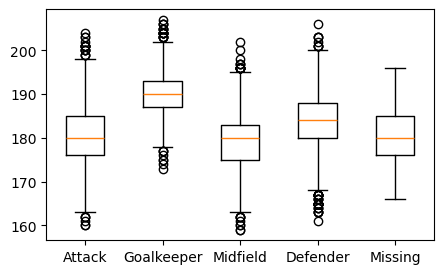

In [32]:
plt.figure(figsize=(5,3))
pos = df["position"].unique()
data = [df.loc[df["position"] == p, "height_in_cm"] for p in pos]
plt.boxplot(x=data)
plt.xticks(ticks=range(1, len(pos) + 1),labels=pos)
plt.show()

In [41]:
def boxplots(df: pd.DataFrame, x: str, y: str, title: str = "", ylabel: str = "") -> None:
    plt.figure(figsize = (5,3))
    hts_box = sns.boxplot(data = df,y = y,x = x)
    hts_box.set(
        title = title,
        ylabel = ylabel)
    plt.axhline(df[y].mean(), label =" Mean", linestyle = "--", color = "red")
    plt.legend()
    plt.show()

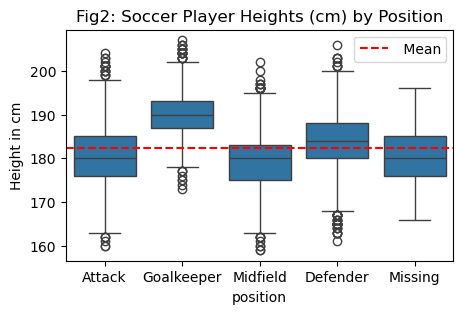

In [42]:
boxplots(df, "position", "height_in_cm", "Fig2: Soccer Player Heights (cm) by Position", "Height in cm")

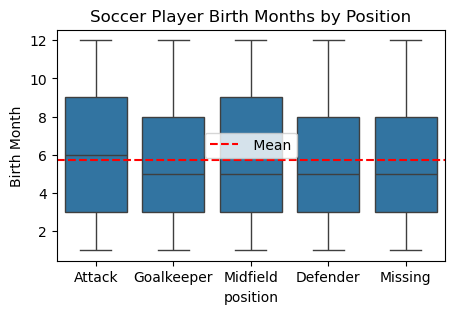

In [43]:
boxplots(df, "position", "month", "Soccer Player Birth Months by Position", "Birth Month")

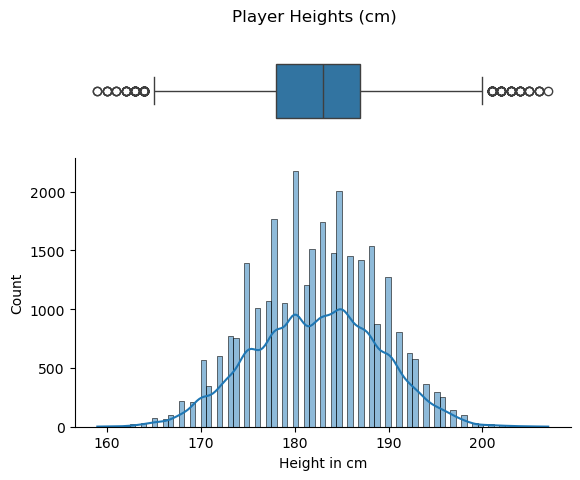

In [54]:
def generate_multiplot(df: pd.DataFrame, col: str, xlabel: str = "", title: str = "") -> None:
    fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, height_ratios = [2, 8])
    box = sns.boxplot(data = df, x = col, ax = ax1)
    hist = sns.histplot(data = df, x = col, ax = ax2, kde = True)
    box.set(yticks = [], xticks = [], xlabel = "")
    hist.set(xlabel = xlabel)
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    fig.suptitle(title)

generate_multiplot(df, "height_in_cm", "Height in cm", "Player Heights (cm)")

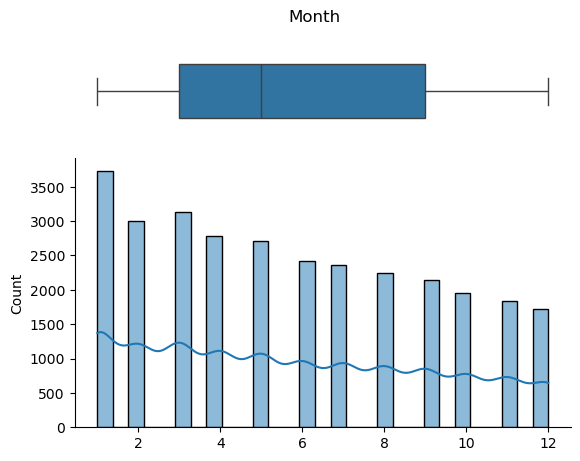

In [58]:
generate_multiplot(df, "month", title = "Month")

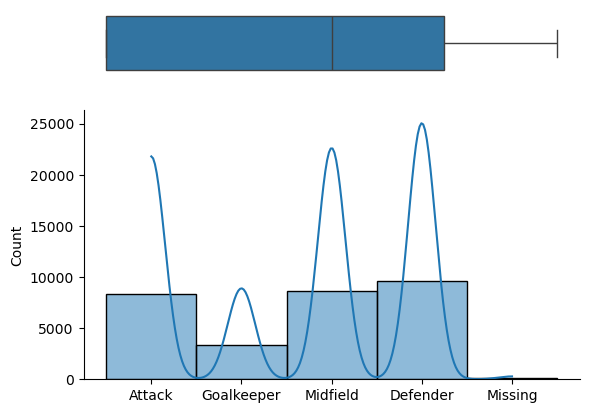

In [56]:
generate_multiplot(df, "position")